# init

In [1]:
PDF_export_active = False

In [1]:
import sled_ROI_tools
import sled_general_tools
import sled_stat_tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os
import sys
import jsimg as jsi
import ttracking as tt
import js_manuscript as jsm
import copy
import glob
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import ttest_ind
from matplotlib import animation
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
import matplotlib as mpl
from scipy import stats
import importlib
import time
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42


In [2]:
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig6"

mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
#mdTitle = 'atLeast1postShift_perAnatRecd_slim2'
#mdTitle = f'atLeast1postShift_anyAnat_slim3'
mdTitle = 'allSlim3'
masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

In [3]:
dffKeys = ['consensus_NMFtc_dff_bc_decon_sp_events']
factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = []
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys)


0 B00002121749
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


1 B00002121774
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285


...

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
21 B00002214001
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/ttracking.py:1785: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


# preLate, postEarly, postLate

In [4]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']
importlib.reload(jsm)
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12


### megaTsep calc

In [5]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
iAnms = {}
aAnms = {}
minTrials = 25
allMinTrials = []
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):

            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preLateMask = allAnmParams[anm]['shiftMask']['preShift_late']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            
            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            earlyAnatMask = np.logical_and(anatMask, earlyMask)
            lateAnatMask = np.logical_and(anatMask, lateMask)
            preLateAnatMask = np.logical_and(anatMask, preLateMask)
            earlytkr = tracker[earlyAnatMask,:]
            latetkr = tracker[lateAnatMask,:]

            eCR = np.sum(earlytkr[:,2]==0)
            eCL = np.sum(earlytkr[:,2]==1)
            lCR = np.sum(latetkr[:,2]==0)
            lCL = np.sum(latetkr[:,2]==1)
            preLateCR = np.sum(tracker[preLateAnatMask,2]==0)
            preLateCL = np.sum(tracker[preLateAnatMask,2]==1)

            if np.all(np.hstack([item>minTrials for item in [preLateCR, preLateCL, eCR, eCL, lCR, lCL]])):
                if anm != 'B00002121777':
                    if dsTsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, preLateCR, preLateCL, np.sum(eCR), np.sum(eCL), np.sum(lCR), np.sum(lCL))
                        allMinTrials.append(np.hstack([preLateCR, preLateCL, eCR,eCL,lCR,lCL]))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([preLateCR, preLateCL, eCR,eCL,lCR,lCL]))
print(np.min(np.hstack(allMinTrials)))

dendrites B00002121774 41 42 152 147 143 97
dendrites B00002213772 135 135 111 84 174 112
dendrites B00002213784 37 33 74 60 153 105
dendrites B00002213908 157 103 101 71 77 67
dendrites B00002213920 101 91 110 109 135 117
dendrites B00002213985 39 55 91 113 157 137
dendrites B00002213997 145 95 72 49 97 72
dendrites B00002213999 49 34 67 45 142 93
somas B00002121774 126 116 53 52 139 96
somas B00002213772 40 46 82 53 173 95
somas B00002213784 145 113 131 89 112 91
somas B00002213785 95 140 64 57 102 83
somas B00002213889 45 46 100 71 126 68
somas B00002213908 38 26 93 58 119 71
somas B00002213920 58 39 114 72 115 127
somas B00002213982 148 140 101 99 124 101
somas B00002213999 154 118 117 84 159 106
26


In [6]:
psWindow = [-3.6,3.6]
useDS = True
anmsToUse = iAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['preShift_late', 'early', 'late']
mods = ['GO','CT']
alignTimes = ['goCues','cTimes']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])
    
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False

            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:705: RuntimeWarning: Mean of empty slice
  FR = np.nanmean(psTsep[FRt,:,:], axis = 0)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:492: RuntimeWarning: Mean of empty slice
  FR = np.nanmean(psTsep[FRt,:,:], axis = 0)


In [11]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(anmsToUse[anat]))
    for phase in phases:
       print(anat," ",phase," ", megaTsepsHH[f'{phase}2'][mod][anat].shape)

dendrites 8
dendrites   preShift_late   (4, 32, 161, 10000)
dendrites   early   (4, 32, 161, 10000)
dendrites   late   (4, 32, 161, 10000)
somas 9
somas   preShift_late   (4, 34, 211, 10000)
somas   early   (4, 34, 211, 10000)
somas   late   (4, 34, 211, 10000)


In [8]:
%%time
CRCL = {}
sqrt = False
nBoot = 10000
for ak, anat in enumerate(anatKeys):
    CRCL[anat] = {}
    for calcPhase in ['pre1','pre2','early1','early2','late1','late2']:#, 'errL']:#', 'early1', 'early2']:#, 'late1', 'late2']:
        CRCL[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):#,'LL']):
            #print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_fast_earlyLate(megaTsepsHH, anat, mod, calcPhase=calcPhase, sqrt = sqrt, nBoot = nBoot)
            CRCL[anat][calcPhase][mod] = allData
print('done')

done
CPU times: user 3min 23s, sys: 4.24 s, total: 3min 27s
Wall time: 3min 28s


In [9]:
%%time
CRCL_full = {}
nBoot = 10000
for ak, anat in enumerate(anatKeys):
    CRCL_full[anat] = {}
    for calcPhase in ['pre','early','late']:
        CRCL_full[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_full(megaTseps,anat, mod, calcPhase = calcPhase, nBoot = nBoot)
            CRCL_full[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre CT
starting dendrites pre GO
starting dendrites early CT
starting dendrites early GO
starting dendrites late CT
starting dendrites late GO
starting somas pre CT
starting somas pre GO
starting somas early CT
starting somas early GO
starting somas late CT
starting somas late GO
done
CPU times: user 42.5 s, sys: 1.26 s, total: 43.7 s
Wall time: 44 s


### vis

/tmp/ipykernel_3597713/3091092480.py:128: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(preCorr*postCorr)


MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.5201 0.8085 0.5838 0.3757 0.626  0.6551 0.0316 0.452  0.2941 0.7443
 0.3705 0.5253 0.9871 0.4101 0.1995 0.2592 1.     0.8122 0.806  0.8688
 0.9957 0.7478 0.4895 0.1688 0.1913 0.4307 0.7608 0.3892 0.4922 0.0624
 0.1318 0.2409]
pVals_Corr = [0.88471579 0.92822857 0.92822857 0.88471579 0.92822857 0.92822857
 0.88471579 0.88471579 0.88471579 0.92822857 0.88471579 0.88471579
 1.         0.88471579 0.88471579 0.88471579 1.         0.92822857
 0.92822857 0.95867586 1.         0.92822857 0.88471579 0.88471579
 0.88471579 0.88471579 0.92822857 0.88471579 0.88471579 0.88471579
 0.88471579 0.88471579]
MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.2404 0.0238 0.0243 0.094  0.3269 0.6798 0.9835 0.7816 0.7053 0.857
 0.5983 0.4854 0.4116 0.8579 0.8003 0.4328 0.3836 0.008  0.0172 0.0083
 0.0156 0.2638 0.1724 0.1674 0.3094 0.1902 0.4378 0.6383 0.763  0.906
 0.4935 0.5026]
pVals_Corr = [0.69934545 0.1296     0.1296  

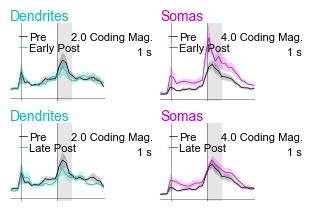

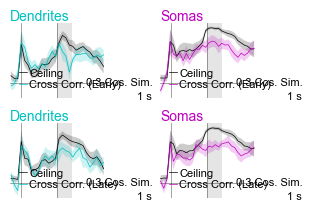

In [10]:
figSize = [3,2]
fontsize = 8
magFig, magAxs = sled_general_tools.clean_subplots(2,2,figSize, constrained_layout = True)
corFig, corAxs = sled_general_tools.clean_subplots(2,2,figSize, constrained_layout = True)

allFigs = [magFig, corFig]
allAxs = [magAxs, corAxs]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
pColors = [(0,0,0),(1,0,0),(0,0.75,0)]
pColors = [(0,0,0),(0.5,0.25,0),(0.5,0.5,0)]
titles = ['Coding Mag.', 'Cos. Sim.']
niceAnatLabels = ['Dendrites', 'Somas']
labels = ['Early Post','Late Post']
alpha = 0.05
method='fdr_bh'
mod = 'GO'
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"

verobse = False
windows = [[3.6,4.6]]
#windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6], [4.7,5.7]]
plotLims = [-3.6,3.6]
xlim = [-3.2,3.2]
ylims = [[[-0.3,8],[-0.5,17]],[[-0.25,1],[-0.25,1]]]
xticks = np.arange(7)-3
linewidth = 0.5

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

for aS, axSet in enumerate(allAxs):
    for ak in range(2):
        for a, ax in enumerate(axSet[:,ak]):
            ax.set_ylim(ylims[aS][ak])
            #     ax.fill_between([0,1],[ylim[0]]*2, [ylim[1]]*2, color = (0,0,0), alpha = 0.1, edgecolor='none')
            ax.set_xlim(xlim)
            ax.text(xlim[0],ylims[aS][ak][1],niceAnatLabels[ak],color=aColors[ak],fontsize=fontsize+2,ha='left',va='bottom')
            
            if mod == 'GO':
                alignTime = 'Go Cue'
                markers = [0,-1.25,-2.45]
                markers = [0,-2.45]
            else:
                alignTime = 'Contact'
                markers = [0]
            for mark in markers:
                ax.plot([mark]*2,ylims[aS][ak],lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            for w, window in enumerate(windows):
                ax.fill_between(np.hstack(window)-3.6,[ylims[aS][ak][0]]*2, [ylims[aS][ak][1]]*2, color = (0,0,0), alpha = 0.1, edgecolor='none')

            vertLabel = titles[aS]+'\n('+errorLabel+')'
            vertLabel = titles[aS]
            if aS == 0:
                plot_scaleBar['horzAdjust']=-0.5
                plot_scaleBar['vertAdjust']=0.7
            else:
                plot_scaleBar['horzAdjust']=-0.5
                plot_scaleBar['vertAdjust']=0.1

            ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)

    for ax in axSet.flatten():
        ax.spines[['top','right','left','bottom']].set_visible(False)

allPs = {}
for ak, anat in enumerate(anatKeys):
    allPs[anat] = {}
    for p, phase in enumerate(phases[1:]):
        allPs[anat][phase] = {}

        if p == 0:
            labelMod = 'Early'
        else:
            labelMod = 'Late'
        labels = [['Pre',labelMod+" Post"],['Ceiling', f'Cross Corr. ({labelMod})']]

        
        pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
        pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
        post1 = CRCL[anat][f'{phase}1'][mod]['axesOrig']
        post2 = CRCL[anat][f'{phase}2'][mod]['axesOrig']
    
        preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
        preNorm = np.linalg.norm(preFull, axis=2)
        postFull = CRCL_full[anat][f'{phase}'][mod]['axesOrig']
        postNorm = np.linalg.norm(postFull, axis=2)
    
        magDif = postNorm-preNorm
    
        preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
        postMag, postCorr = jsm.get_mag_corr(post1, post2)
        mixMag, mixCorr = jsm.get_mag_corr(preFull,postFull)
    
        denom = np.sqrt(preCorr*postCorr)
        mixCorrected = mixCorr/(denom)
    
        mags = [preNorm, postNorm]
        corrs = [denom, mixCorr]
        data2Plot = [mags,corrs]
    
        magDiff = mags[1]-mags[0]
    
        magP = np.sum(magDiff<0, axis=0)/magDiff.shape[0]
        magCorrection_multCorr,magCorrection_pText = sled_stat_tools.multi_test_correction(magP,method,alpha,verobse)

        allPs[anat][phase]['mag'] = magP
        corrP = np.sum(mixCorrected>1, axis = 0)/mixCorrected.shape[0]
        allPs[anat][phase]['corr'] = corrP

        for d, dataSet in enumerate(data2Plot):
            if p == 0 and d == 0:
                col = 0
            elif p == 0 and d ==1:
                col = 2
            elif p == 1 and d == 0:
                col = 1
            else:
                col = 3
            ax = allAxs[d][p,ak]
            for j, data in enumerate(dataSet):
                if j == 0:
                    color = (0,0,0)
                else:
                    color = aColors[ak]
                mean = np.nanmean(data,axis=0)
                med = np.nanmedian(data,axis=0)
                std = np.nanstd(data,axis=0, ddof = 1)
                sem = std / np.sqrt(data.shape[0])
                low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                x = np.linspace(plotLims[0],plotLims[1],len(mean))
                plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
                if error == 'CI':
                    mainPlot = med
                    errorLow = low
                    errorHigh = high
                elif error == 'sem':
                    mainPlot = mean
                    errorLow = mean-sem
                    errorHigh = mean+sem
                elif error == 'std':
                    mainPlot = mean
                    errorLow = mean-std
                    errorHigh = mean+std

                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = color, alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = '-',color = color, label = labels[d][j],lw = linewidth)
            ax.set_yticks([])
            ax.set_xticks([])
            ax.set_xlim(xlim)
            ax.set_ylim(ylims[d][ak])
            if d == 0:
                loc = 'upper left'
            else:
                loc = 'lower left'
            ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

figName = 'Fig6_earlyLate_magProjections.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(magFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
figName = 'Fig6_earlyLate_cosProjections.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(corFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page


sled_general_tools.display_clean_subplots(magFig,magAxs)
sled_general_tools.display_clean_subplots(corFig,corAxs)

0.78 p = 0.0618 n.s.
dendrites 0.0
0.76 p = 0.0362 *
-0.03 p = 0.6532 n.s.
1.61 p = 0.0012 *
somas 0.25
1.09 p = 0.511 n.s.
-0.52 p = 0.0 *
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.0003 0.0188]
pVals_Corr = [0.0006 0.0188]
Bbox(x0=0.125, y0=0.10999999999999999, x1=0.9, y1=0.88)


/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)


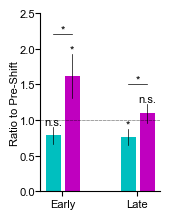

/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


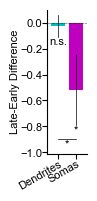

In [11]:
figsize0 = [1.8,2.3]
figsize1 = [0.5,1.6]
linewidth = 0.5
fontsize = 8
fig = [[],[]]
axs = [[],[]]
fig[0], axs[0] = sled_general_tools.clean_subplots(1,1,figsize0,facecolor='none',constrained_layout = False)
fig[1], axs[1] = sled_general_tools.clean_subplots(1,1,figsize1,facecolor='none',constrained_layout = False)
pColors = [(1,0,0),(0,0.75,0),(0,0,0)]
aColors = [(0,1,1),(1,0,1)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
window = [3.6,4.6]
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    if a==0:
        testLine = 1
    else:
        testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)


allDists = {}
allPs = {}
alphas = [1,1]
for ak, anat in enumerate(anatKeys):
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = np.linalg.norm(CRCL_full[anat]['pre'][mod]['axesOrig'], axis = 2)
    preMean = np.nanmean(pre[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    
    early = np.linalg.norm(CRCL_full[anat]['early'][mod]['axesOrig'], axis = 2)
    earlyMean = np.nanmean(early[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    
    late = np.linalg.norm(CRCL_full[anat]['late'][mod]['axesOrig'], axis = 2)
    lateMean = np.nanmean(late[:,int(window[0]*F):int(window[1]*F)], axis = 1)

    earlyDif = earlyMean/preMean
    lateDif = lateMean/preMean
    withinPost = lateDif-earlyDif
    
    data2Plot = [earlyDif, lateDif, withinPost]
    for d, data in enumerate(data2Plot):
        if d<2:
            ax = axs[0]
        else:
            ax = axs[1]

        wData = data
        allDists[anat][pLabels[d]] = wData
    
        mean = np.nanmean(wData,axis=0)
        med = np.nanmedian(wData,axis=0)
        std = np.nanstd(wData,axis=0, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std


        
        if d!=2:
            testLine = 1
        else:
            testLine = 0
            
        tail1 = np.sum(wData<testLine)/wData.shape[0]
        tail2 = np.sum(wData>testLine)/wData.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = sled_stat_tools.pstar(pVal,inclP = False)
        print(f'{mainPlot:.2f} p = {pVal} {pText}')

        allPs[anat][pLabels[d]]=pVal
        if d!=2:
            x = (ak/4)+(d)
        else:
            x = ak/4
        if d == 0:
            print(f'{anat} {x}')
        ax.bar(x, mainPlot, width = barwidth, color = aColors[ak], alpha = alphas[ak])
        ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw = linewidth)
        if mainPlot<0:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'
        ax.text(x, text_ypos, pText, fontsize=fontsize,ha='center',va=va)
                
######################################################
ys = [2.5,.5]
for d in range(2):
    ax = axs[d]
    if d == 0:
        ys = [2.2,1.5]
    else:
        ys = [-0.9]
    if d == 0:
        pVals = []
        for j in range(2):
            dData = allDists['dendrites'][pLabels[j]]
            sData = allDists['somas'][pLabels[j]]
            
            pVal = np.sum(sData<dData)/wData.shape[0]
            pVals.append(pVal)
        pVals = np.hstack(pVals)
     
        multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

        for w in range(2):
            ax.plot([w,w+0.25],[ys[w],ys[w]],lw = linewidth, color = (0,0,0))
            ax.text(w+.125,ys[w],pText[w],fontsize=fontsize,ha='center',va='bottom')
        ax.set_xticks(np.arange(2)+.12)
        ax.set_xticklabels(['Early', 'Late'],fontsize=fontsize)
        ax.set_ylim([0,2.5])
        ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
        ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
    else:
        dData = allDists['dendrites']['Late-Early']
        sData = allDists['somas']['Late-Early']
        
        pVal = np.sum(sData>dData)/wData.shape[0]
        pText = sled_stat_tools.pstar(pVal,inclP = False)
 
        ax.plot([0,0.25],[ys[0],ys[0]],lw = linewidth, color = (0,0,0))
        ax.text(.125,ys[0],pText,fontsize=fontsize,ha='center',va='top')
        
        ax.set_xlim([-0.15,0.4])
        ax.set_xticks([0,0.25])
        ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')
        ax.set_ylim([-1.01,0.1])
        ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
        ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
    if d!=1:
        ax.set_ylabel('Ratio to Pre-Shift',fontsize=fontsize,labelpad=0)
    else:
        ax.set_ylabel('Late-Early Difference',fontsize=fontsize,labelpad=0)
        pos = ax.get_position()
        print(pos)
        ax.set_position([0.125,0,0.8,0.9])


figName = 'Fig6_earlyLate_ratios.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig[0],bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
figName = 'Fig6_earlyLate_diffs.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig[1],bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

sled_general_tools.display_clean_subplots(fig[0],axs[0])
sled_general_tools.display_clean_subplots(fig[1],axs[1])

dendrites Early mean: -21.588 std: 12.165 p: 0.0618
dendrites Late mean: -24.227 std: 11.244 p: 0.0362
dendrites Late-Early mean: -2.639 std: 8.315 p: 0.6532

somas Early mean: 61.190 std: 30.938 p: 0.0012
somas Late mean: 9.220 std: 13.815 p: 0.5110
somas Late-Early mean: -51.970 std: 27.229 p: 0.0000

MultCompar Correction method = holm alpha = 0.05
pVals      = [0.0003 0.0188]
pVals_Corr = [0.0006 0.0188]


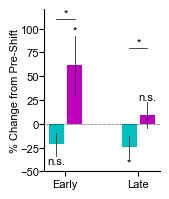

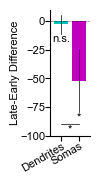

In [14]:
figsize0 = [1.8,2.1]
figsize1 = [0.5,1.4]
linewidth = 0.5
fontsize = 8
fig = [[],[]]
axs = [[],[]]
fig[0], axs[0] = sled_general_tools.clean_subplots(1,1,figsize0,facecolor='none',constrained_layout = False)
fig[1], axs[1] = sled_general_tools.clean_subplots(1,1,figsize1,facecolor='none',constrained_layout = False)
pColors = [(1,0,0),(0,0.75,0),(0,0,0)]
aColors = [(0,1,1),(1,0,1)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
window = [3.6,4.6]
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    
    testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)


allDists = {}
allPs = {}
alphas = [1,1]
for ak, anat in enumerate(anatKeys):
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = np.linalg.norm(CRCL_full[anat]['pre'][mod]['axesOrig'], axis = 2)
    preMean = np.nanmean(pre[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    
    early = np.linalg.norm(CRCL_full[anat]['early'][mod]['axesOrig'], axis = 2)
    earlyMean = np.nanmean(early[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    
    late = np.linalg.norm(CRCL_full[anat]['late'][mod]['axesOrig'], axis = 2)
    lateMean = np.nanmean(late[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    
    earlyDif = (earlyMean-preMean) / np.absolute(preMean) * 100
    lateDif = (lateMean-preMean) / np.absolute(preMean) * 100
    withinPost = lateDif-earlyDif
    
    data2Plot = [earlyDif, lateDif, withinPost]
    for d, data in enumerate(data2Plot):
        if d<2:
            ax = axs[0]
        else:
            ax = axs[1]

        wData = data
        allDists[anat][pLabels[d]] = wData
 
        mean = np.nanmean(wData,axis=0)
        med = np.nanmedian(wData,axis=0)
        std = np.nanstd(wData,axis=0, ddof = 1)
        sem = std / np.sqrt(wData.shape[0])
        low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std

        testLine = 0
            
        tail1 = np.sum(wData<testLine)/wData.shape[0]
        tail2 = np.sum(wData>testLine)/wData.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = sled_stat_tools.pstar(pVal,inclP = False)
        print(anat, pLabels[d], f'mean: {mainPlot:.3f}', f'std: {std:.3f}', f'p: {pVal:.4f}')

        allPs[anat][pLabels[d]]=pVal
        if d!=2:
            x = (ak/4)+(d)
        else:
            x = ak/4
    
        ax.bar(x, mainPlot, width = barwidth, color = aColors[ak], alpha = alphas[ak])
        ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw = linewidth)
        if mainPlot<0:
            text_ypos = errorLow
            va='top'
        else:
            text_ypos = errorHigh
            va = 'bottom'
        ax.text(x, text_ypos, pText, fontsize=fontsize,ha='center',va=va)
    print('')
    
######################################################
for d in range(2):
    ax = axs[d]
    if d == 0:
        ys = [110,80]
    else:
        ys = [-90]
    if d == 0:
        pVals = []
        for j in range(2):
            dData = allDists['dendrites'][pLabels[j]]
            sData = allDists['somas'][pLabels[j]]
            
            pVal = np.sum(sData<dData)/wData.shape[0]
            pVals.append(pVal)
        pVals = np.hstack(pVals)

        multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

        for w in range(2):
            ax.plot([w,w+0.25],[ys[w],ys[w]],lw = linewidth, color = (0,0,0))
            ax.text(w+.125,ys[w],pText[w],fontsize=fontsize,ha='center',va='bottom')
        ax.set_xticks(np.arange(2)+.12)
        ax.set_xticklabels(['Early', 'Late'],fontsize=fontsize)
        ax.set_ylim([-50,120])
        ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 2) #
        ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
    else:
        dData = allDists['dendrites']['Late-Early']
        sData = allDists['somas']['Late-Early']
        
        pVal = np.sum(sData>dData)/wData.shape[0]
        pText = sled_stat_tools.pstar(pVal,inclP = False)

        ax.plot([0,0.25],[ys[0],ys[0]],lw = linewidth, color = (0,0,0))
        ax.text(.125,ys[0],pText,fontsize=fontsize,ha='center',va='top')
        
        ax.set_xlim([-0.15,0.4])
        ax.set_xticks([0,0.25])
        ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')
        ax.set_ylim([-100,10])
        ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
        ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
    if d!=1:
        ax.set_ylabel('% Change from Pre-Shift',fontsize=fontsize,labelpad=0)
    else:
        ax.set_ylabel('Late-Early Difference',fontsize=fontsize,labelpad=0)
        pos = ax.get_position()
        ax.set_position([0.125,0,0.8,0.9])


figName = 'Fig6_earlyLate_perChange.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig[0],bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
figName = 'Fig6_earlyLate_perChange_diffs.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig[1],bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page

sled_general_tools.display_clean_subplots(fig[0],axs[0])
sled_general_tools.display_clean_subplots(fig[1],axs[1])

#### 4 windows

/tmp/ipykernel_885956/2261588305.py:136: RuntimeWarning: invalid value encountered in sqrt
  denom = np.sqrt(preCorr*postCorr)


MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.5254 0.8144 0.5828 0.3797 0.6234 0.6533 0.0276 0.4563 0.2977 0.7463
 0.3715 0.5285 0.9872 0.4199 0.205  0.2619 1.     0.8122 0.8165 0.8698
 0.9962 0.7543 0.4933 0.1687 0.1887 0.437  0.7633 0.3927 0.492  0.065
 0.1306 0.2471]
pVals_Corr = [0.89010526 0.93314286 0.93248    0.89010526 0.93314286 0.93314286
 0.8832     0.89010526 0.89010526 0.93314286 0.89010526 0.89010526
 1.         0.89010526 0.89010526 0.89010526 1.         0.93314286
 0.93314286 0.95977931 1.         0.93314286 0.89010526 0.89010526
 0.89010526 0.89010526 0.93314286 0.89010526 0.89010526 0.89010526
 0.89010526 0.89010526]
MultCompar Correction method = fdr_bh alpha = 0.05
pVals      = [0.2395 0.0214 0.0272 0.0911 0.3119 0.6863 0.9827 0.78   0.7052 0.8573
 0.5937 0.4937 0.4017 0.8567 0.8074 0.4306 0.372  0.0094 0.0156 0.007
 0.0176 0.2585 0.1658 0.1596 0.3092 0.1847 0.4378 0.6405 0.7589 0.913
 0.5105 0.5027]
pVals_Corr = [0.68933333 0.13696    0.1450666

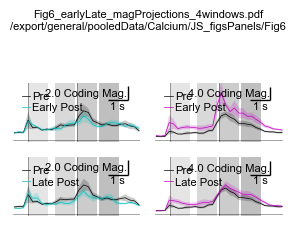

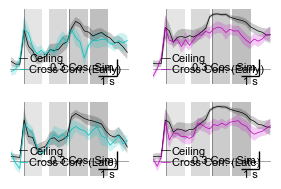

In [145]:
figSize = [3,2]
fontsize = 8

magFig, magAxs = sled_general_tools.clean_subplots(2,2,figSize, facecolor='none',constrained_layout = False)
corFig, corAxs = sled_general_tools.clean_subplots(2,2,figSize, facecolor='none',constrained_layout = False)
linewidth = 0.5
allFigs = [magFig, corFig]
allAxs = [magAxs, corAxs]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
pColors = [(0,0,0),(1,0,0),(0,0.75,0)]
pColors = [(0,0,0),(0.5,0.25,0),(0.5,0.5,0)]
titles = ['Coding Mag.', 'Cos. Sim.']
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
niceAnatLabels = ['Dendrites', 'Somas']
labels = ['Early Post','Late Post']
alpha = 0.05
method='fdr_bh'
mod = 'GO'
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"

verobse = False
windows = [[3.6,4.6]]
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
plotLims = [-3.6,3.6]
xlim = [-3.2,3.2]
ylims = [[[-0.3,8],[-0.5,17]],[[-0.25,1],[-0.25,1]]]
xticks = np.arange(7)-3
linewidth = 0.5

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

for aS, axSet in enumerate(allAxs):
    for ak in range(2):
        for a, ax in enumerate(axSet[:,ak]):
            ax.set_ylim(ylims[aS][ak])
         
            ax.set_xlim(xlim)
      
            if mod == 'GO':
                alignTime = 'Go Cue'
                markers = [0,-1.25,-2.45]
                markers = [0,-2.45]
            else:
                alignTime = 'Contact'
                markers = [0]
            for mark in markers:
                ax.plot([mark]*2,ylims[aS][ak],lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
            for w, window in enumerate(windows):
                ax.fill_between(np.hstack(window)-3.6,[ylims[aS][ak][0]]*2, [ylims[aS][ak][1]]*2, color = (0,0,0), alpha = w*0.05+0.1, edgecolor='none')
            vertLabel = titles[aS]+'\n('+errorLabel+')'
            vertLabel = titles[aS]
            if aS == 0:
                plot_scaleBar['horzAdjust']=0.1
                plot_scaleBar['vertAdjust']=0.7
            else:
                plot_scaleBar['horzAdjust']=0.1
                plot_scaleBar['vertAdjust']=0.1

            ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)

    for ax in axSet.flatten():
        ax.spines[['top','right','left','bottom']].set_visible(False)

allPs = {}
for ak, anat in enumerate(anatKeys):
    allPs[anat] = {}
    for p, phase in enumerate(phases[1:]):
        allPs[anat][phase] = {}

        if p == 0:
            labelMod = 'Early'
        else:
            labelMod = 'Late'
        labels = [['Pre',labelMod+" Post"],['Ceiling', f'Cross Corr. ({labelMod})']]

        
        pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
        pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
        post1 = CRCL[anat][f'{phase}1'][mod]['axesOrig']
        post2 = CRCL[anat][f'{phase}2'][mod]['axesOrig']
    
        preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
        preNorm = np.linalg.norm(preFull, axis=2)
        postFull = CRCL_full[anat][f'{phase}'][mod]['axesOrig']
        postNorm = np.linalg.norm(postFull, axis=2)
    
        magDif = postNorm-preNorm
    
        preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
        postMag, postCorr = jsm.get_mag_corr(post1, post2)
        mixMag, mixCorr = jsm.get_mag_corr(preFull,postFull)
    
        denom = np.sqrt(preCorr*postCorr)
        mixCorrected = mixCorr/(denom)
    
        mags = [preNorm, postNorm]
        corrs = [denom, mixCorr]
        data2Plot = [mags,corrs]
    
        magDiff = mags[1]-mags[0]
    
        magP = np.sum(magDiff<0, axis=0)/magDiff.shape[0]

        magCorrection_multCorr,magCorrection_pText = sled_stat_tools.multi_test_correction(magP,method,alpha,verobse)

        allPs[anat][phase]['mag'] = magP
    
        corrP = np.sum(mixCorrected>1, axis = 0)/mixCorrected.shape[0]

        mixCorrection_multCorr,mixCorrection_pText = sled_stat_tools.multi_test_correction(corrP,method,alpha,verobse)
        allPs[anat][phase]['corr'] = corrP

        for d, dataSet in enumerate(data2Plot):
            if p == 0 and d == 0:
                col = 0
            elif p == 0 and d ==1:
                col = 2
            elif p == 1 and d == 0:
                col = 1
            else:
                col = 3
            ax = allAxs[d][p,ak]
            for j, data in enumerate(dataSet):
                if j == 0:
                    color = (0,0,0)
                else:
                    color = aColors[ak]
          
                mean = np.nanmean(data,axis=0)
                med = np.nanmedian(data,axis=0)
                std = np.nanstd(data,axis=0, ddof = 1)
                sem = std / np.sqrt(data.shape[0])
                low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                x = np.linspace(plotLims[0],plotLims[1],len(mean))
                plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
                if error == 'CI':
                    mainPlot = med
                    errorLow = low
                    errorHigh = high
                elif error == 'sem':
                    mainPlot = mean
                    errorLow = mean-sem
                    errorHigh = mean+sem
                elif error == 'std':
                    mainPlot = mean
                    errorLow = mean-std
                    errorHigh = mean+std

                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = color, alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = '-',color = color, label = labels[d][j],lw = linewidth)
            ax.set_yticks([])
            ax.set_xticks([])
            ax.set_xlim(xlim)
            ax.set_ylim(ylims[d][ak])
            if d == 0:
                loc = 'upper left'
            else:
                loc = 'lower left'
            ax.legend(frameon=False,fontsize=fontsize,loc=loc,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 



figName = 'Fig6_earlyLate_magProjections_4windows.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(magFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(magFig,magAxs)

figName = 'Fig6_earlyLate_cosProjections_4windows.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(corFig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(corFig,corAxs)
plt.show()



dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.338  0.8082 0.1146 0.8114]
pVals_Corr = [1.     1.     0.4584 1.    ]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.3886 0.     0.074  0.9514]
pVals_Corr = [0.7772 0.     0.222  0.9514]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.5972 0.0048 0.7114 0.9194]
pVals_Corr = [1.     0.0192 1.     1.    ]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.     0.0198 0.001  0.0118]
pVals_Corr = [0.     0.0236 0.003  0.0236]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [2.000e-04 1.324e-01 5.180e-01 5.780e-02]
pVals_Corr = [0.0008 0.2648 0.518  0.1734]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.4142 0.051  0.     0.0122]
pVals_Corr = [0.4142 0.102  0.     0.0366]
Early Post-Shift
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.0015 0.0188 0.0006 0.0158]
pVals_Corr = [0.0045 

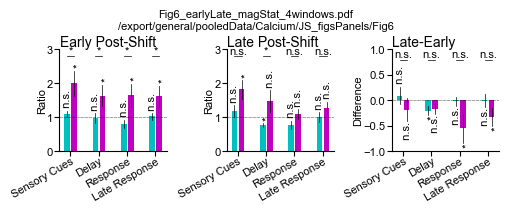

In [155]:
figSize = (5,1.75)
fontsize = 8
fig, axs = sled_general_tools.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(0,0,0)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift', 'Late Post-Shift','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5


allDists = {}
allPs = {}
alphas = [1,1]
for ak, anat in enumerate(anatKeys):
    
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = np.linalg.norm(CRCL_full[anat]['pre'][mod]['axesOrig'], axis = 2)
    early = np.linalg.norm(CRCL_full[anat]['early'][mod]['axesOrig'], axis = 2)
    late = np.linalg.norm(CRCL_full[anat]['late'][mod]['axesOrig'], axis = 2)
    earlyDif = early/pre
    lateDif = late/pre
    withinPost = lateDif-earlyDif
    data2Plot = [earlyDif, lateDif, withinPost]
    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)
            allDists[anat][pLabels[d]].append(wData)



            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std


            
            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            if d!=2:
                testLine = 1
            else:
                testLine = 0
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal
            
        allPs[anat][pLabels[d]]=anatPs
 
        multCorr,anatPText = sled_stat_tools.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])

        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
            else:
                ha='left'
            rotation = 90
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)
     
for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    if a!=2:
        testLine = 1
    else:
        testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

ys = [2.8,2.8,.8]
for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)
    pVals = np.hstack(pVals)

    print(pLabels[d])
    multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    if d!=2:
        ax.set_ylabel('Ratio',fontsize=fontsize,labelpad = 0)
        ax.set_ylim([0,3])
        ax.text(-0.25,3,pLabels[d],fontsize=fontsize+2,ha='left',va='bottom')
    else:
        ax.set_ylabel('Difference',fontsize=fontsize,labelpad = 0)
        ax.set_ylim([-1,1])
        ax.text(-0.25,1,pLabels[d],fontsize=fontsize+2,ha='left',va='bottom')
figName = 'Fig6_earlyLate_magStat_4windows.pdf'
sled_general_tools.set_dynamic_suptitle(fig,figName+"\n"+str(figSaveDir),margin = 0.1,\
            fontsize=fontsize,color=(0,0,0),va='bottom')
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)

/tmp/ipykernel_885956/1874776662.py:59: RuntimeWarning: invalid value encountered in sqrt
  denomEarly = np.sqrt(preCorr*earlyCorr)
/tmp/ipykernel_885956/1874776662.py:61: RuntimeWarning: invalid value encountered in sqrt
  denomLate = np.sqrt(preCorr*lateCorr)
/tmp/ipykernel_885956/1874776662.py:64: RuntimeWarning: invalid value encountered in sqrt
  withinDenom = np.sqrt(earlyCorr*lateCorr)
/tmp/ipykernel_885956/1874776662.py:79: RuntimeWarning: Mean of empty slice
  wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)/np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)


dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2106 0.4102 0.008  0.141 ]
pVals_Corr = [0.423 0.423 0.032 0.423]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.6008 0.2796 0.003  0.039 ]
pVals_Corr = [0.6008 0.5592 0.012  0.117 ]
dendrites
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.4672 0.0454 0.0074 0.2092]
pVals_Corr = [0.4672 0.1362 0.0296 0.4184]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.4766 0.2616 0.     0.    ]
pVals_Corr = [0.5232 0.5232 0.     0.    ]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2402 0.2436 0.     0.0004]
pVals_Corr = [0.4804 0.4804 0.     0.0012]
somas
MultCompar Correction method = holm alpha = 0.05
pVals      = [4.104e-01 1.246e-01 0.000e+00 2.000e-04]
pVals_Corr = [0.4104 0.2492 0.     0.0006]
Early Post-Shift
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.9084 0.9047 0.2499 0.6622]
pVals_Corr = [1.     1.  

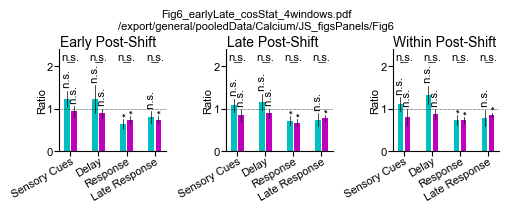

In [154]:
figSize = (5,1.75)
fontsize = 8
fig, axs = sled_general_tools.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(1,0,1)]

aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift', 'Late Post-Shift','Within Post-Shift']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']

windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

nWindows = len(windows)
allDists = {}
allPs = {}
alphas = [1,1]
postShiftRaw = []
postShiftIntCorr = []
for ak, anat in enumerate(anatKeys):
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
    pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
    early1 = CRCL[anat][f'early1'][mod]['axesOrig']
    early2 = CRCL[anat][f'early2'][mod]['axesOrig']
    late1 = CRCL[anat][f'late1'][mod]['axesOrig']
    late2 = CRCL[anat][f'late2'][mod]['axesOrig']

    preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
    earlyFull = CRCL_full[anat][f'early'][mod]['axesOrig']
    lateFull = CRCL_full[anat][f'late'][mod]['axesOrig']
    
    preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
    earlyMag, earlyCorr = jsm.get_mag_corr(early1, early2)
    lateMag, lateCorr = jsm.get_mag_corr(late1, late2)

    mixEarlyMag, mixEarlyCorr = jsm.get_mag_corr(preFull,earlyFull)
    mixLateMag, mixLateCorr = jsm.get_mag_corr(preFull,lateFull)
    mixMixMag, mixMixCorr = jsm.get_mag_corr(earlyFull,lateFull)

    # denom =  np.sqrt(abs(preCorr*postCorr))
    denomEarly = np.sqrt(preCorr*earlyCorr)
    mixEarlyCorrected = mixEarlyCorr/(denomEarly) #boot, time
    denomLate = np.sqrt(preCorr*lateCorr)
    mixLateCorrected = mixLateCorr/(denomLate)

    withinDenom = np.sqrt(earlyCorr*lateCorr)
    mixMixCorrected = mixMixCorr/withinDenom
    data2Plot = [mixEarlyCorr, mixLateCorr, mixMixCorr]
    denoms = [denomEarly, denomLate, withinDenom]

    
    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data
        denom = denoms[d]

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)/np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)
            allDists[anat][pLabels[d]].append(wData)


            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std


            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            testLine = 1
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal
            
        allPs[anat][pLabels[d]]=anatPs

        print(anat)
        multCorr,anatPText = sled_stat_tools.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])
        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
            else:
                ha='left'
            rotation = 90
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)
for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    testLine = 1
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

ys = [2.1,2.1,2.1]
for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)

    pVals = np.hstack(pVals)

    print(pLabels[d])
    multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)
    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim([0,2.4])
    ax.text(-0.25,2.4,pLabels[d],fontsize=fontsize+2,ha='left',va='bottom')
    ax.set_ylabel('Ratio',fontsize=fontsize,labelpad=0)
figName = 'Fig6_earlyLate_cosStat_4windows.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)

#### 4 windows Percent Change Aaron this is the lastest version

               dendrites Early Post-Shift vs. Pre Sensory Cues vs Response two tails pval 0.0262
----------------
dendrites Early Post-Shift vs. Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.338  0.8082 0.1146 0.8114]
pVals_Corr = [1.     1.     0.4584 1.    ]
               dendrites Late Post-Shift vs Pre Sensory Cues vs Response two tails pval 0.079
----------------
dendrites Late Post-Shift vs Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.3886 0.     0.074  0.9514]
pVals_Corr = [0.7772 0.     0.222  0.9514]
               dendrites Late-Early Sensory Cues vs Response two tails pval 0.5074
----------------
dendrites Late-Early 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.5972 0.0048 0.7114 0.9194]
pVals_Corr = [1.     0.0192 1.     1.    ]
               somas Early Post-Shift vs. Pre Sensory Cues vs Response two tails pval 0.0426
----------------
somas Early Post-Shift vs. Pre 2tail v 0


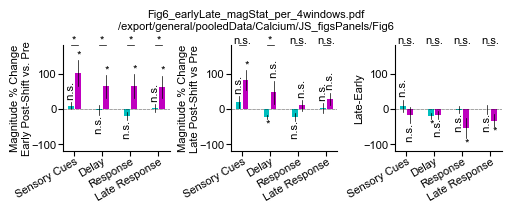

In [140]:
figSize = (5,1.75)
fontsize = 8
fig, axs = sled_general_tools.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(0,0,0)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
ylim = [-120,180]
ys = [180,180,180]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift vs. Pre', 'Late Post-Shift vs Pre','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
dataType = 'Magnitude'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

allDists = {}
allPs = {}
alphas = [1,1]
for ak, anat in enumerate(anatKeys):
    
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = np.linalg.norm(CRCL_full[anat]['pre'][mod]['axesOrig'], axis = 2)
    early = np.linalg.norm(CRCL_full[anat]['early'][mod]['axesOrig'], axis = 2)
    late = np.linalg.norm(CRCL_full[anat]['late'][mod]['axesOrig'], axis = 2)
    earlyPer = (early-pre)/np.absolute(pre) * 100
    latePer = (late-pre)/np.absolute(pre) * 100
    post_pre = latePer-earlyPer
    data2Plot = [earlyPer, latePer, post_pre]
    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            wData = np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1)
            allDists[anat][pLabels[d]].append(wData)

            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std

            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            testLine = 0
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal

        w1 = 0
        data1 = allDists[anat][pLabels[d]][w1]
        w2 = 2
        data2 = allDists[anat][pLabels[d]][w2]
        tail1 = np.sum(data1<data2)/data1.shape[0]
        tail2 = np.sum(data1>data2)/data1.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        print('----------------')
        print(f'{anat} {pLabels[d]} {windowLabels[w1]} vs {windowLabels[w2]} two tails pval {pVal}')

        
        allPs[anat][pLabels[d]]=anatPs
        print('----------------')
        print(f'{anat} {pLabels[d]} 2tail v {testLine}')
        multCorr,anatPText = sled_stat_tools.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])

        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
                rotation = 90
            else:
                ha='center'
                rotation = 0
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)
            
for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)
    pVals = np.hstack(pVals)
    print('----------------')
    print(f'dend > soma {pLabels[d]}')
    multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)

    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim(ylim)
    if d!=2:
        ax.set_ylabel(dataType+' % Change\n'+pLabels[d],fontsize=fontsize,labelpad = 0)
    else:
        ax.set_ylabel('Late-Early',fontsize=fontsize,labelpad = 0)
figName = 'Fig6_earlyLate_magStat_per_4windows.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)

/tmp/ipykernel_885956/1526665549.py:63: RuntimeWarning: invalid value encountered in sqrt
  denomEarly = np.sqrt(preCorr*earlyCorr)
/tmp/ipykernel_885956/1526665549.py:65: RuntimeWarning: invalid value encountered in sqrt
  denomLate = np.sqrt(preCorr*lateCorr)
/tmp/ipykernel_885956/1526665549.py:68: RuntimeWarning: invalid value encountered in sqrt
  withinDenom = np.sqrt(earlyCorr*lateCorr)
/tmp/ipykernel_885956/1526665549.py:86: RuntimeWarning: Mean of empty slice
  wData = (np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1) - np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)) / np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1) * 100


----------------
dendrites Early Post-Shift vs. Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.2106 0.4102 0.008  0.141 ]
pVals_Corr = [0.423 0.423 0.032 0.423]
----------------
dendrites Early Post-Shift vs. Pre Sensory Cues vs Response two tails pval 0.0298
----------------
dendrites Late Post-Shift vs Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.6008 0.2796 0.003  0.039 ]
pVals_Corr = [0.6008 0.5592 0.012  0.117 ]
----------------
dendrites Late Post-Shift vs Pre Sensory Cues vs Response two tails pval 0.0264
----------------
dendrites Late-Early 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.347  0.9664 0.5858 0.6642]
pVals_Corr = [1. 1. 1. 1.]
----------------
dendrites Late-Early Sensory Cues vs Response two tails pval 0.3152
----------------
somas Early Post-Shift vs. Pre 2tail v 0
MultCompar Correction method = holm alpha = 0.05
pVals      = [0.4766 0.2616 0.     0.    ]
pVals_Corr = [

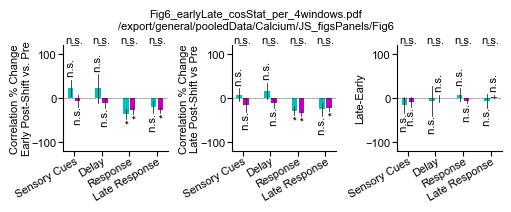

In [141]:
figSize = (5,1.75)
fontsize = 8
fig, axs = sled_general_tools.clean_subplots(1,3,figSize, sharey = False, constrained_layout = True)
pColors = [(1,0,0),(0,1,0),(1,0,1)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.2
ylim = [-120,120]
ys = [120,120,120]
barwidth = 0.2
windowLabels = ['Sensory Cues', 'Delay', 'Response', 'Late Response']
pLabels = ['Early Post-Shift vs. Pre', 'Late Post-Shift vs Pre','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"
niceAnatLabels = ['Dendrites','Somas']
windows = [[1.15,2.15],[2.5,3.5],[3.6,4.6],[4.7,5.7]]
mod = 'GO'
dataType = 'Correlation'
nWindows = len(windows)
testLS = ':'
testDashes = (5,1)
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5

nWindows = len(windows)
allDists = {}
allPs = {}
alphas = [1,1]
postShiftRaw = []
postShiftIntCorr = []
for ak, anat in enumerate(anatKeys):
    allDists[anat] = {}
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre1 = CRCL[anat][f'pre1'][mod]['axesOrig']#boot, time, roi
    pre2 = CRCL[anat][f'pre2'][mod]['axesOrig']
    early1 = CRCL[anat][f'early1'][mod]['axesOrig']
    early2 = CRCL[anat][f'early2'][mod]['axesOrig']
    late1 = CRCL[anat][f'late1'][mod]['axesOrig']
    late2 = CRCL[anat][f'late2'][mod]['axesOrig']

    preFull = CRCL_full[anat]['pre'][mod]['axesOrig']
    earlyFull = CRCL_full[anat][f'early'][mod]['axesOrig']
    lateFull = CRCL_full[anat][f'late'][mod]['axesOrig']
    
    preMag, preCorr = jsm.get_mag_corr(pre1, pre2)
    earlyMag, earlyCorr = jsm.get_mag_corr(early1, early2)
    lateMag, lateCorr = jsm.get_mag_corr(late1, late2)

    mixEarlyMag, mixEarlyCorr = jsm.get_mag_corr(preFull,earlyFull)
    mixLateMag, mixLateCorr = jsm.get_mag_corr(preFull,lateFull)
    mixMixMag, mixMixCorr = jsm.get_mag_corr(earlyFull,lateFull)

    denomEarly = np.sqrt(preCorr*earlyCorr)
    mixEarlyCorrected = mixEarlyCorr/(denomEarly) #boot, time
    denomLate = np.sqrt(preCorr*lateCorr)
    mixLateCorrected = mixLateCorr/(denomLate)

    withinDenom = np.sqrt(earlyCorr*lateCorr)
    mixMixCorrected = mixMixCorr/withinDenom

    data2Plot = [mixEarlyCorr, mixLateCorr, mixMixCorr]
    denoms = [denomEarly, denomLate, withinDenom]

    
    for d, data in enumerate(data2Plot):
        ax = axs[d]
        allDists[anat][pLabels[d]] = []#data
        denom = denoms[d]

        anatMains = np.zeros(nWindows)
        anatErrors = np.zeros([2,nWindows])
        anatPs = np.zeros(nWindows)
        for w, window in enumerate(windows):
            if d !=2:
                wData = (np.nanmean(data[:,int(window[0]*F):int(window[1]*F)], axis = 1) - np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1)) / np.nanmean(denom[:,int(window[0]*F):int(window[1]*F)], axis = 1) * 100
            else:
                wData = allDists[anat][pLabels[1]][w] - allDists[anat][pLabels[0]][w]
            allDists[anat][pLabels[d]].append(wData)


            mean = np.nanmean(wData,axis=0)
            med = np.nanmedian(wData,axis=0)
            std = np.nanstd(wData,axis=0, ddof = 1)
            sem = std / np.sqrt(wData.shape[0])
            low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std


            anatMains[w] = copy.deepcopy(mainPlot)
            anatErrors[0,w] = copy.deepcopy(errorLow)
            anatErrors[1,w] = copy.deepcopy(errorHigh)
            
            testLine = 0
                
            tail1 = np.sum(wData<testLine)/wData.shape[0]
            tail2 = np.sum(wData>testLine)/wData.shape[0]
            twoTails = 2 * min(tail1, tail2)
            pVal = min(twoTails, 1.0)
            anatPs[w] = pVal
            
        allPs[anat][pLabels[d]]=anatPs
       
        print('----------------')
        print(f'{anat} {pLabels[d]} 2tail v {testLine}')
        multCorr,anatPText = sled_stat_tools.multi_test_correction(anatPs,method='holm',alpha = 0.05,verbose = True)

        ax.bar(np.arange(nWindows)+(ak/4), anatMains, width = barwidth, color = aColors[ak], alpha = alphas[ak])
        for i in range(nWindows):
            ax.plot(np.array([i,i])+(ak/4),anatErrors[:,i],color = (0,0,0),lw = linewidth)
            if anatMains[i]<0:
                text_ypos = anatErrors[0,i]
                va='top'
            else:
                text_ypos = anatErrors[1,i]
                va = 'bottom'
            if 'n.s.' in anatPText[i]:
                ha='center'
            else:
                ha='left'
            rotation = 90
            ax.text(i+(ak/4), text_ypos, " "+anatPText[i], fontsize=fontsize,ha=ha,va=va,rotation = rotation)

        w1 = 0
        data1 = allDists[anat][pLabels[d]][w1]
        w2 = 2
        data2 = allDists[anat][pLabels[d]][w2]
        tail1 = np.sum(data1<data2)/data1.shape[0]
        tail2 = np.sum(data1>data2)/data1.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        print('----------------')
        print(f'{anat} {pLabels[d]} {windowLabels[w1]} vs {windowLabels[w2]} two tails pval {pVal}')

for a, ax in enumerate(axs):
    ax.spines[['top','right']].set_visible(False)
    testLine = 0
    ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)

for d in range(3):
    ax = axs[d]
    y = ys[d]
    pVals = []
    for w in range(nWindows):
        dData = allDists['dendrites'][pLabels[d]][w]
        sData = allDists['somas'][pLabels[d]][w]
        
        pVal = np.sum(sData<dData)/wData.shape[0]
        pVals.append(pVal)
    pVals = np.hstack(pVals)
    print('----------------')
    print(f'dend > soma {pLabels[d]}')
    multCorr,pText = sled_stat_tools.multi_test_correction(pVals,method='holm',alpha = 0.05,verbose = True)
    for w in range(nWindows):
        ax.plot([w,w+0.25],[y,y], lw = linewidth, color = (0,0,0))
        ax.text(w+.125,y,pText[w],fontsize=fontsize,ha='center',va='bottom')
    ax.set_xticks(np.arange(4)+.12)
    ax.set_xticklabels(windowLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
    ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
    ax.set_ylim(ylim)
    if d!=2:
        ax.set_ylabel(dataType+' % Change\n'+pLabels[d],fontsize=fontsize,labelpad = 0)
    else:
        ax.set_ylabel('Late-Early',fontsize=fontsize,labelpad = 0)
figName = 'Fig6_earlyLate_cosStat_per_4windows.pdf'
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,axs)